In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
from pathlib import Path

In [23]:

file_path = "/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04/2026-04-avon-and-somerset-street.csv"

crime_folder = Path("/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04")

crime_files = list(
    crime_folder.glob("*-street.csv")
)

len(crime_files)

41

In [24]:
crime_files[:5]

[PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04/2026-04-surrey-street.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04/2026-04-humberside-street.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04/2026-04-nottinghamshire-street.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04/2026-04-west-yorkshire-street.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/external/crime/2026-04/2026-04-hampshire-street.csv')]

In [25]:
crime_dfs = []

for file in crime_files:
    temp_df = pd.read_csv(file)
    crime_dfs.append(temp_df)

df = pd.concat(
    crime_dfs,
    ignore_index=True
)

In [26]:
df.shape

(478865, 12)

In [27]:
df.columns

Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='str')

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 478865 entries, 0 to 478864
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               399066 non-null  str    
 1   Month                  478865 non-null  str    
 2   Reported by            478865 non-null  str    
 3   Falls within           478865 non-null  str    
 4   Longitude              472523 non-null  float64
 5   Latitude               472523 non-null  float64
 6   Location               478865 non-null  str    
 7   LSOA code              461132 non-null  object 
 8   LSOA name              461132 non-null  object 
 9   Crime type             478865 non-null  str    
 10  Last outcome category  391480 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(3), str(6)
memory usage: 110.9+ MB


In [9]:
df.describe()

,Longitude,Latitude,Context
count,10000.000000,10000.000000,0.0
mean,-2.599202,51.413544,NaN
std,0.166409,0.081024,NaN
min,-5.285022,50.211505,NaN
25%,-2.619656,51.380159,NaN
50%,-2.588470,51.440945,NaN
75%,-2.541317,51.463864,NaN
max,0.165692,51.861677,NaN


In [28]:
df.describe(include="object")

/var/folders/p1/h04ydjvj7hl31dlpwq7pc6yh0000gn/T/ipykernel_32931/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Crime ID,Month,Reported by,Falls within,Location,LSOA code,LSOA name,Crime type,Last outcome category
count,399066,478865,478865,478865,478865,461132,461132,478865,391480
unique,397359,1,41,41,106223,32789,32789,14,13
top,ae5d4ba6151226f9b12b90f4bd79125ee3224c8c5e9144...,2026-04,Metropolitan Police Service,Metropolitan Police Service,On or near Parking Area,E01035716,Westminster 013G,Violence and sexual offences,Under investigation
freq,4,478865,91664,91664,20225,742,742,165101,200723


In [37]:
df.isnull().sum()

Crime ID                  79799
Month                         0
Reported by                   0
Falls within                  0
Longitude                  6342
Latitude                   6342
Location                      0
LSOA code                 17733
LSOA name                 17733
Crime type                    0
Last outcome category     87385
Context                  478865
dtype: int64

In [11]:
(df.isnull().sum() / len(df)) * 100

Crime ID                  16.05
Month                      0.00
Reported by                0.00
Falls within               0.00
Longitude                  0.00
Latitude                   0.00
Location                   0.00
LSOA code                  0.00
LSOA name                  0.00
Crime type                 0.00
Last outcome category     16.05
Context                  100.00
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(570)

In [13]:
df["Crime ID"].duplicated().sum()

np.int64(1725)

In [38]:
df["Crime type"].value_counts().head(10)

Crime type
Violence and sexual offences    165101
Anti-social behaviour            79799
Shoplifting                      44274
Criminal damage and arson        36345
Public order                     32349
Other theft                      30886
Vehicle crime                    23893
Burglary                         16497
Drugs                            15964
Other crime                      10409
Name: count, dtype: int64

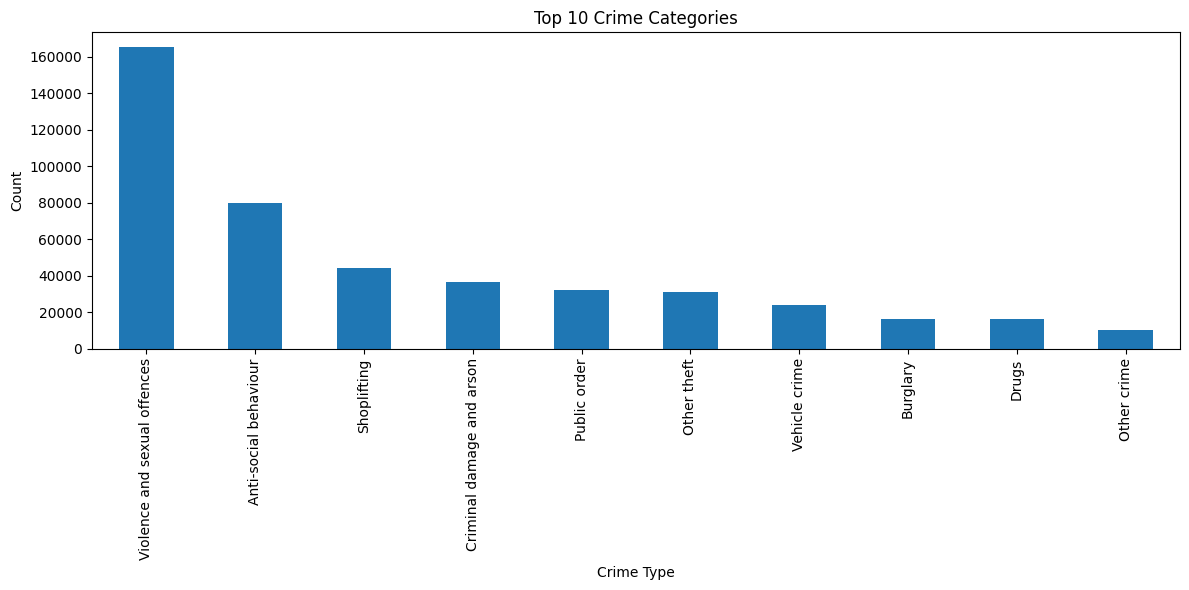

In [29]:
crime_counts = (
    df["Crime type"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

crime_counts.plot(kind="bar")

plt.title("Top 10 Crime Categories")
plt.xlabel("Crime Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/outputs/plots/top_10_crime_categories.png",
    bbox_inches="tight"
)

plt.show()

In [40]:
(
    df["Crime type"]
    .value_counts(normalize=True)
    * 100
).round(2)

Crime type
Violence and sexual offences    34.48
Anti-social behaviour           16.66
Shoplifting                      9.25
Criminal damage and arson        7.59
Public order                     6.76
Other theft                      6.45
Vehicle crime                    4.99
Burglary                         3.45
Drugs                            3.33
Other crime                      2.17
Theft from the person            1.65
Robbery                          1.38
Possession of weapons            1.02
Bicycle theft                    0.84
Name: proportion, dtype: float64

In [31]:
(
    crime_counts
    / len(df)
    * 100
).round(2)

Crime type
Violence and sexual offences    34.48
Anti-social behaviour           16.66
Shoplifting                      9.25
Criminal damage and arson        7.59
Public order                     6.76
Other theft                      6.45
Vehicle crime                    4.99
Burglary                         3.45
Drugs                            3.33
Other crime                      2.17
Name: count, dtype: float64

In [15]:
df["Month"].value_counts().sort_index()

Month
2026-04    10000
Name: count, dtype: int64

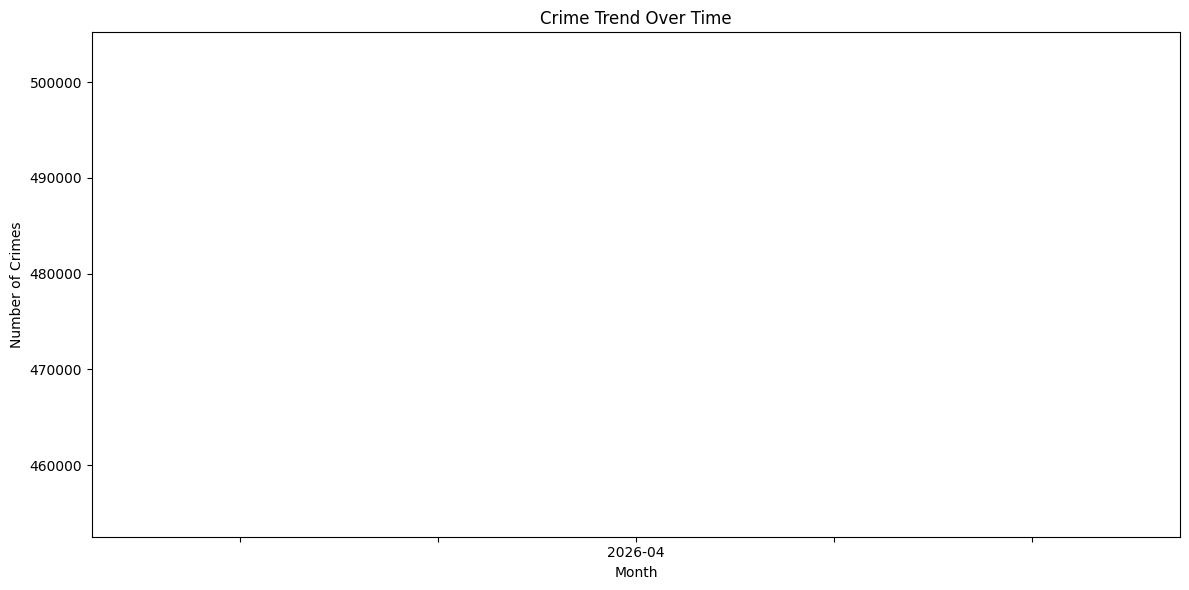

In [32]:
monthly_crimes = (
    df["Month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

monthly_crimes.plot()

plt.title("Crime Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")

plt.tight_layout()

plt.savefig(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/outputs/plots/monthly_crime_trend.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
df["LSOA name"]\
    .value_counts()\
    .head(20)

LSOA name
Bristol 061A                         264
Bristol 054D                         195
Bristol 025E                         157
North Somerset 020C                  148
Bath and North East Somerset 007A    146
Bristol 061C                         132
Bristol 059D                         122
Bristol 060C                          94
Bath and North East Somerset 007B     90
Bristol 014D                          89
Bristol 060D                          75
Bristol 029D                          74
Bristol 054B                          74
Bristol 048B                          70
Bristol 048A                          66
Bristol 043C                          65
Bristol 053F                          65
Bristol 061B                          64
Bristol 039E                          60
Bristol 054G                          58
Name: count, dtype: int64

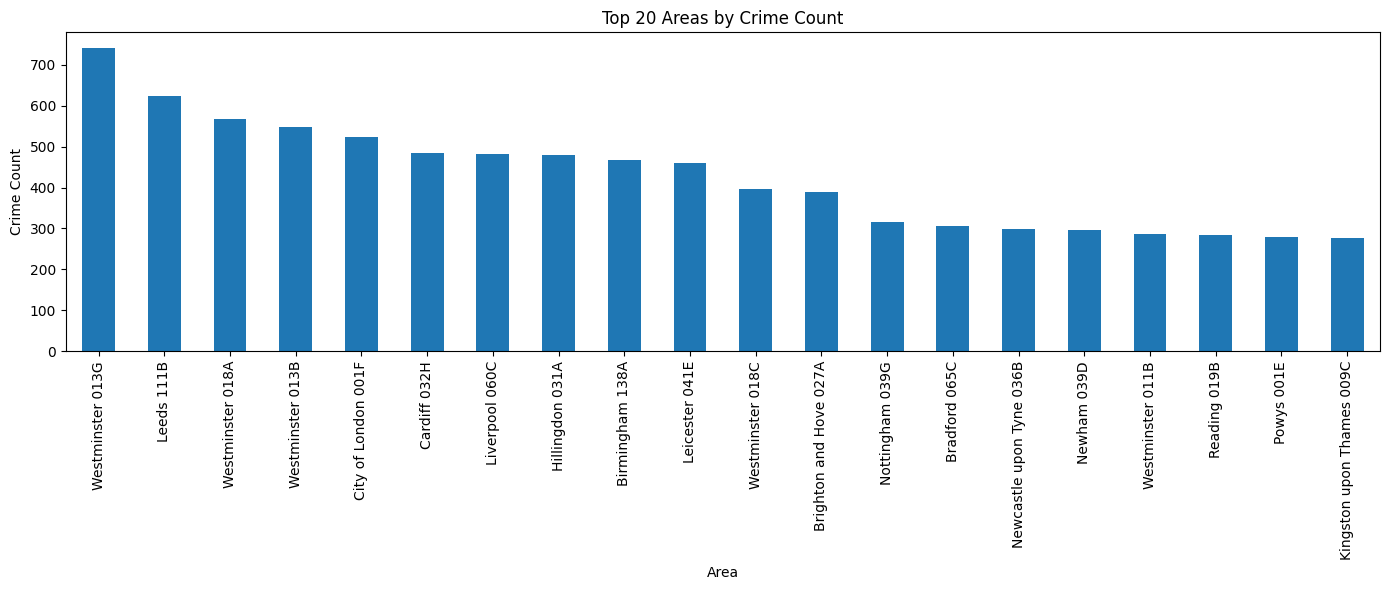

In [33]:
top_areas = (
    df["LSOA name"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14,6))

top_areas.plot(kind="bar")

plt.title("Top 20 Areas by Crime Count")
plt.xlabel("Area")
plt.ylabel("Crime Count")

plt.tight_layout()

plt.savefig(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/outputs/plots/top_20_crime_areas.png",
    bbox_inches="tight"
)

plt.show()

In [34]:
df["Falls within"].value_counts()

Falls within
Metropolitan Police Service           91664
West Midlands Police                  26616
West Yorkshire Police                 24265
Avon and Somerset Constabulary        16657
Thames Valley Police                  16377
Kent Police                           14704
South Yorkshire Police                14700
Sussex Police                         14411
Essex Police                          14073
Lancashire Constabulary               13737
Hampshire Constabulary                13653
Northumbria Police                    12745
Devon & Cornwall Police               12193
Merseyside Police                     12146
Police Service of Northern Ireland    11508
Nottinghamshire Police                11165
South Wales Police                    10502
Staffordshire Police                   9150
Hertfordshire Constabulary             9070
Derbyshire Constabulary                8993
Humberside Police                      8528
West Mercia Police                     8456
Leicestershire Poli

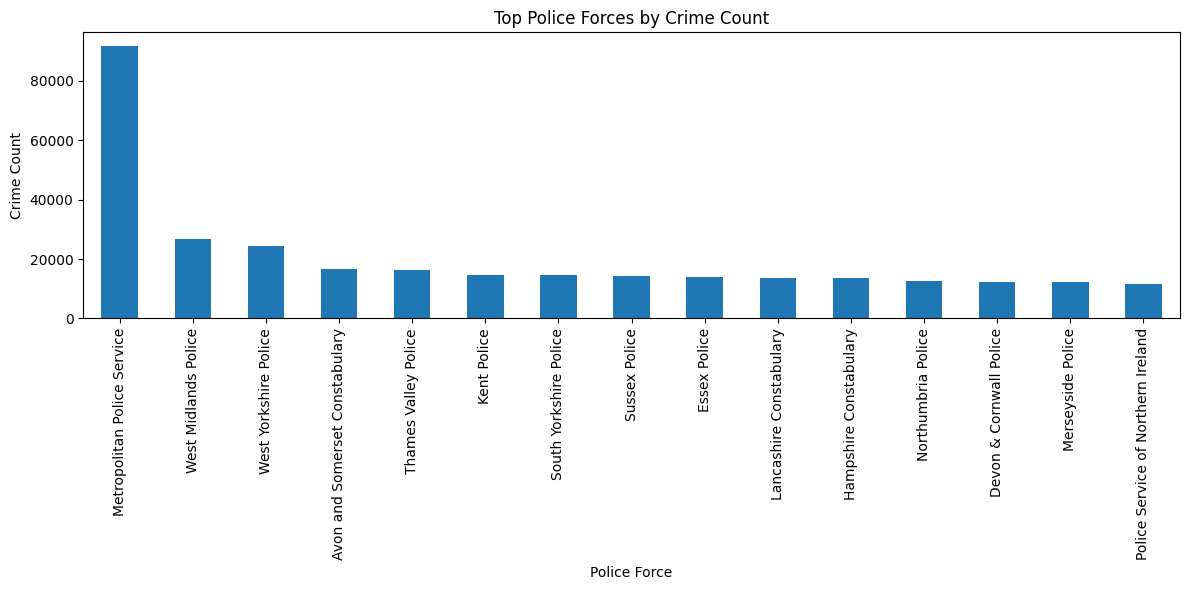

In [35]:
force_counts = (
    df["Falls within"]
    .value_counts()
)

plt.figure(figsize=(12,6))

force_counts.head(15).plot(kind="bar")

plt.title("Top Police Forces by Crime Count")

plt.xlabel("Police Force")

plt.ylabel("Crime Count")

plt.tight_layout()

plt.savefig(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/outputs/plots/crime_by_police_force.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
df["Last outcome category"].value_counts()

Last outcome category
Under investigation                                    3414
Investigation complete; no suspect identified          2687
Unable to prosecute suspect                            1883
Awaiting court outcome                                  207
Further investigation is not in the public interest      70
Action to be taken by another organisation               54
Local resolution                                         40
Offender given a caution                                 12
Suspect charged as part of another case                  12
Further action is not in the public interest              9
Formal action is not in the public interest               7
Name: count, dtype: int64

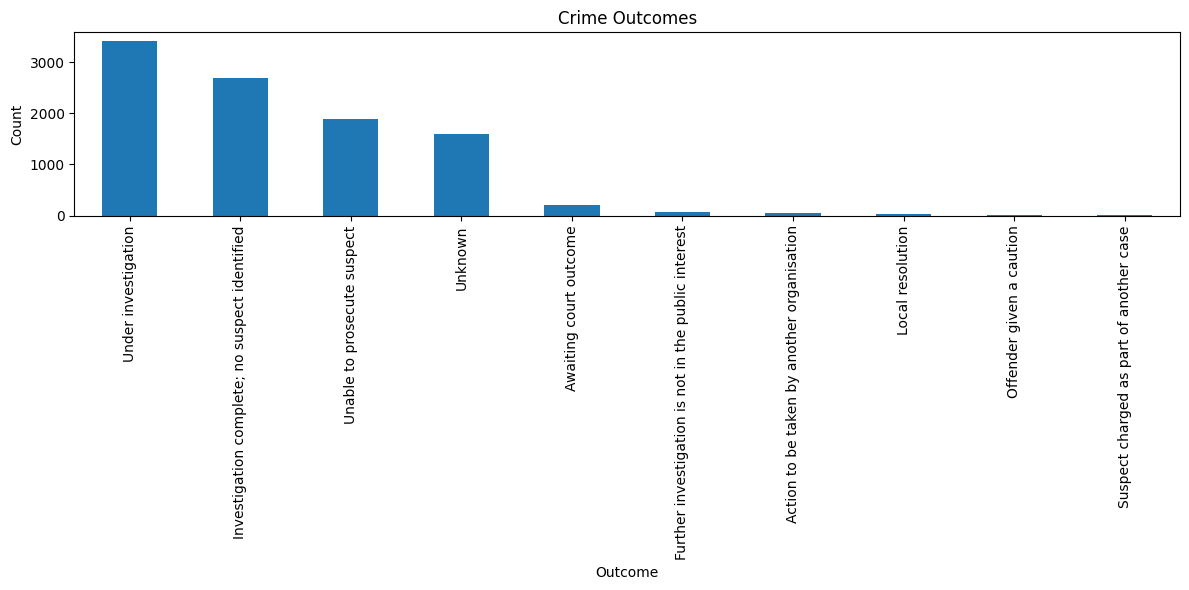

In [21]:
outcomes = (
    df["Last outcome category"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

outcomes.plot(kind="bar")

plt.title("Crime Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/outputs/plots/crime_outcomes.png",
    bbox_inches="tight"
)

plt.show()

In [39]:
df[df["Crime type"] == "Anti-social behaviour"]["Crime ID"].isnull().sum()

np.int64(79799)

In [41]:
df["Falls within"].value_counts().head(15)

Falls within
Metropolitan Police Service           91664
West Midlands Police                  26616
West Yorkshire Police                 24265
Avon and Somerset Constabulary        16657
Thames Valley Police                  16377
Kent Police                           14704
South Yorkshire Police                14700
Sussex Police                         14411
Essex Police                          14073
Lancashire Constabulary               13737
Hampshire Constabulary                13653
Northumbria Police                    12745
Devon & Cornwall Police               12193
Merseyside Police                     12146
Police Service of Northern Ireland    11508
Name: count, dtype: int64

In [42]:
df["Last outcome category"].value_counts().head(15)

Last outcome category
Under investigation                                    200723
Investigation complete; no suspect identified           99056
Unable to prosecute suspect                             65511
Awaiting court outcome                                  15028
Local resolution                                         6215
Action to be taken by another organisation               1977
Offender given a caution                                 1152
Further investigation is not in the public interest       916
Formal action is not in the public interest               468
Further action is not in the public interest              244
Offender given penalty notice                             133
Suspect charged as part of another case                    56
Offender given a drugs possession warning                   1
Name: count, dtype: int64

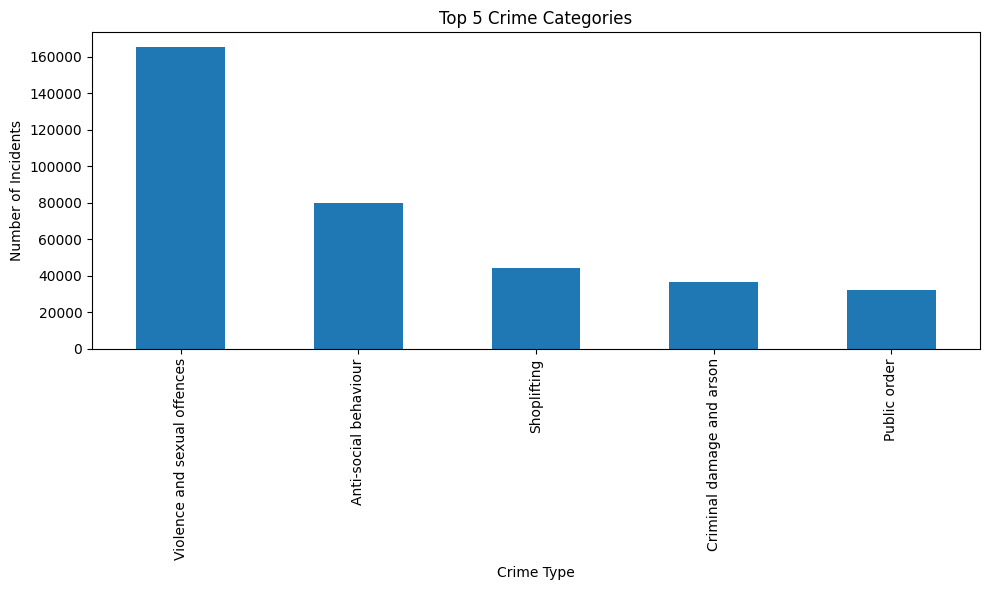

In [43]:
top_5_crimes = (
    df["Crime type"]
    .value_counts()
    .head(5)
)

plt.figure(figsize=(10,6))

top_5_crimes.plot(kind="bar")

plt.title("Top 5 Crime Categories")

plt.xlabel("Crime Type")
plt.ylabel("Number of Incidents")

plt.tight_layout()

plt.savefig(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/outputs/plots/top_5_crime_categories.png",
    bbox_inches="tight"
)

plt.show()